# 🚗 Driver Wellness AI
## End-to-End Integrated Driver Monitoring System

### Milestone 4 – Final Integrated Notebook

---

## Team Members

| Module | Team Member |
|---------|-------------|
| 🎥 Video-Based Fatigue Detection | Kushagra Barodekar |
| 😊 Landmark-Based Fatigue Detection | Shiwani |
| 🚘 Driver Activity Recognition | Shubham |
| 📱 Seat Belt Detection | Sohini |
| 🚬 Smoking & Drinking Detection | Ravina |

---

## Project Overview

Driver Wellness AI combines multiple independently trained deep learning models into a single
integrated **Driver Wellness pipeline**. Each model analyzes the same input video independently
and produces a standardized prediction. A central **Risk Fusion Engine** combines every module's
output into one overall **Driver Wellness Score**.

This notebook is the **production integration layer**. It does **not** redesign, retrain, or
reimplement any model. Every adapter below wraps the *existing* inference logic documented in the
per-module Technical Integration Specifications / Module Manager Contracts, exactly as trained.

## System Pipeline

```
                         Input Driving Video
                                  │
                                  ▼
             ┌────────────────────────────────────────────┐
             │              AI Detection Modules           │
             ├────────────────────────────────────────────┤
             │  🎥 Video Fatigue Detection                 │
             │  😊 Landmark Fatigue Detection              │
             │  🚘 Driver Activity Recognition             │
             │  🚬 Smoking & Drinking Detection             │
             │  📱 Seat Belt Detection                     │
             └────────────────────────────────────────────┘
                                  │
                                  ▼
                         Risk Fusion Engine
                                  │
                                  ▼
                     Driver Wellness Score (0-100)
                                  │
                                  ▼
                        Dashboard / Report
```

## Notebook Structure

1. Install Dependencies
2. Mount Google Drive
3. Configuration
4. Model Registry
5. Upload Video
6. Core SDK (`PredictionResult`, `InferenceContext`, `BaseModelAdapter`, `AdapterRegistry`, `DriverWellnessModuleManager`)
7. Video Fatigue Adapter
8. Driver Activity Adapter
9. Landmark Adapter
10. Smoking Adapter
11. Seatbelt Adapter
12. `DriverWellnessModuleManager` — register & wire up every adapter
13. Risk Fusion Engine
14. Dashboard
15. End-to-End Demo

## 1. Install Dependencies

Colab already ships `torch`, `torchvision`, `opencv-python`, `numpy`, `Pillow`, `pandas`, and
`matplotlib`. Only `ultralytics` (Smoking & Drinking / Seatbelt YOLO adapters) and `mediapipe`
(Landmark Fatigue adapter) need to be installed explicitly.

In [52]:
# ==========================================================
# Driver Wellness AI — Dependency Installation
# ==========================================================
# Ultralytics -> Smoking/Drinking + Seatbelt YOLO adapters (Sections 10-11)
# MediaPipe   -> Landmark Fatigue adapter, face landmark extraction (Section 9)
%pip -q install "ultralytics>=8.3.0" "mediapipe>=0.10.14" >/dev/null 2>&1

print("=" * 80)
print("Dependency installation complete")
print("=" * 80)

import ultralytics
import mediapipe

print(f"ultralytics : {ultralytics.__version__}")
print(f"mediapipe   : {mediapipe.__version__}")

Dependency installation complete
ultralytics : 8.4.112
mediapipe   : 1.0.0


## 2. Mount Google Drive

All model checkpoints live under `MODEL_ROOT` on Google Drive (see Section 3 for the exact path).

In [53]:
# ==========================================================
# Mount Google Drive
# ==========================================================
from google.colab import drive

drive.mount("/content/drive")

print("=" * 80)
print("Google Drive mounted at /content/drive")
print("=" * 80)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted at /content/drive


## 3. Configuration

Every numeric constant below is taken directly from the per-module Technical Integration
Specifications / Module Manager Contracts (source of truth) — nothing here is invented.

In [54]:
# ==========================================================
# Driver Wellness AI — Configuration
# ==========================================================
from pathlib import Path

import torch

# ----------------------------------------------------------
# Paths
# ----------------------------------------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive/DS_AI_LAB_Group_5")
MODEL_ROOT = DRIVE_ROOT / "Models"

# ----------------------------------------------------------
# Device (auto-detected — never hardcoded)
# ----------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------------------------------------
# Shared ImageNet normalization (Video Fatigue + Driver Activity backbones)
# ----------------------------------------------------------
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# ----------------------------------------------------------
# Video Fatigue — EfficientNet-B0 + BiLSTM (Section 7)
# ----------------------------------------------------------
VIDEO_FATIGUE_SEQUENCE_LENGTH = 16
VIDEO_FATIGUE_IMAGE_SIZE = (224, 224)
VIDEO_FATIGUE_HIDDEN_SIZE = 256
VIDEO_FATIGUE_NUM_LAYERS = 1
VIDEO_FATIGUE_BIDIRECTIONAL = True
VIDEO_FATIGUE_DROPOUT = 0.3
VIDEO_FATIGUE_CLASS_NAMES = ["Low Risk", "Medium Risk", "High Risk"]
VIDEO_FATIGUE_RISK_MAP = {"Low Risk": 0.2, "Medium Risk": 0.6, "High Risk": 1.0}

# ----------------------------------------------------------
# Driver Activity — MobileNetV3-Large (Section 8)
# ----------------------------------------------------------
DRIVER_ACTIVITY_IMAGE_SIZE = (224, 224)
DRIVER_ACTIVITY_CLASS_NAMES = [
    "other_activities",
    "safe_driving",
    "talking_phone",
    "texting_phone",
    "turning",
]
DRIVER_ACTIVITY_RISK_MAP = {
    "safe_driving": 0.05,
    "turning": 0.20,
    "talking_phone": 0.60,
    "other_activities": 0.70,
    "texting_phone": 0.85,
}
# Frame-sampling stride used when running the (single-image) classifier over a video,
# matching the reused `VideoActivityProcessor(frame_skip=5)` default from the spec.
DRIVER_ACTIVITY_FRAME_SKIP = 5

# ----------------------------------------------------------
# Landmark Fatigue — MediaPipe + 2-layer LSTM (Section 9)
# ----------------------------------------------------------
LANDMARK_WINDOW_SIZE = 45
LANDMARK_FEATURE_NAMES = ["EAR", "MAR", "Pitch", "Yaw", "Roll"]
LANDMARK_INPUT_SIZE = 5
LANDMARK_HIDDEN_SIZE = 128
LANDMARK_NUM_LAYERS = 2
LANDMARK_NUM_CLASSES = 3
LANDMARK_ACTION_LABELS = ["Normal", "Talking", "Yawning"]
LANDMARK_FATIGUE_THRESHOLD = 0.15  # yawn_proportion >= this -> Drowsy (per spec)
LANDMARK_NORMALIZATION_STATS_PATH = MODEL_ROOT / "m4_normalization_stats_ws45.csv"
MEDIAPIPE_FACE_LANDMARKER_PATH = MODEL_ROOT / "face_landmarker.task"
MEDIAPIPE_FACE_LANDMARKER_URL = (
    "https://storage.googleapis.com/mediapipe-models/face_landmarker/"
    "face_landmarker/float16/latest/face_landmarker.task"
)

# ----------------------------------------------------------
# Smoking & Drinking — YOLOv8n (Section 10)
# ----------------------------------------------------------
SMOKING_IMGSZ = 640
SMOKING_CONF_THRESHOLD = 0.25
SMOKING_RISK_WEIGHTS = {"smoking": 0.8, "drinking": 0.5}
SMOKING_BOTH_DETECTED_RISK = 0.9

# ----------------------------------------------------------
# Seat Belt & Phone Usage Detection — YOLOv8n (Section 11)
# ----------------------------------------------------------
SEATBELT_PHONE_IMGSZ = 640
SEATBELT_PHONE_CONF_THRESHOLD = 0.40
SEATBELT_PHONE_CLASS_NAMES = {0: "Phone", 1: "Seatbelt"}
SEATBELT_PHONE_RISK_MAP = {"Phone": 0.85, "Seatbelt": 0.0}

# ----------------------------------------------------------
# Risk Fusion weights (Section 13)
# ----------------------------------------------------------
RISK_FUSION_WEIGHTS = {
    "video_fatigue": 0.35,
    "landmark_fatigue": 0.25,
    "driver_activity": 0.20,
    "smoking": 0.10,
    "seatbelt": 0.10,
}
assert abs(sum(RISK_FUSION_WEIGHTS.values()) - 1.0) < 1e-9, "Risk fusion weights must sum to 1.0"

print("=" * 80)
print("Driver Wellness AI — Configuration Loaded")
print("=" * 80)
print(f"Device      : {DEVICE}")
print(f"MODEL_ROOT  : {MODEL_ROOT}")
print(f"Risk Fusion Weights : {RISK_FUSION_WEIGHTS}")

Driver Wellness AI — Configuration Loaded
Device      : cuda
MODEL_ROOT  : /content/drive/MyDrive/DS_AI_LAB_Group_5/Models
Risk Fusion Weights : {'video_fatigue': 0.35, 'landmark_fatigue': 0.25, 'driver_activity': 0.2, 'smoking': 0.1, 'seatbelt': 0.1}


## 4. Model Registry

Reused from the existing integrated notebook's registry/availability-check pattern, refactored to
key off the same module keys used by `RISK_FUSION_WEIGHTS` above.

In [55]:
# ==========================================================
# Driver Wellness AI — Model Registry
# ==========================================================
import os

import pandas as pd
from IPython.display import display

MODEL_REGISTRY = {
    "video_fatigue": {
        "name": "🎥 Video Fatigue Detection",
        "checkpoint": str(MODEL_ROOT / "Video_Fatigue.pth"),
        "weight": RISK_FUSION_WEIGHTS["video_fatigue"],
    },
    "landmark_fatigue": {
        "name": "😊 Landmark Fatigue Detection",
        "checkpoint": str(MODEL_ROOT / "Landmark_Fatigue.pt"),
        "weight": RISK_FUSION_WEIGHTS["landmark_fatigue"],
    },
    "driver_activity": {
        "name": "🚘 Driver Activity Recognition",
        "checkpoint": str(MODEL_ROOT / "Driver_Activity.pth"),
        "weight": RISK_FUSION_WEIGHTS["driver_activity"],
    },
    "smoking": {
        "name": "🚬 Smoking & Drinking Detection",
        "checkpoint": str(MODEL_ROOT / "Smoking_And_Drinking.pt"),
        "weight": RISK_FUSION_WEIGHTS["smoking"],
    },
    "seatbelt": {
        "name": "📱 Seat Belt & Phone Usage Detection",
        "checkpoint": str(MODEL_ROOT / "SeatBelt_And_Phone.pt"),
        "weight": RISK_FUSION_WEIGHTS["seatbelt"],
    },
}

system_status = []
available_models = []

print("=" * 80)
print("Driver Wellness AI - Model Availability")
print("=" * 80)

for module_key, module in MODEL_REGISTRY.items():
    exists = os.path.exists(module["checkpoint"])
    status = "Available" if exists else "Missing"
    icon = "✅" if exists else "❌"

    print(f"{icon} {module['name']}")

    if exists:
        available_models.append(module_key)

    system_status.append(
        {
            "Module": module["name"],
            "Checkpoint": os.path.basename(module["checkpoint"]),
            "Weight": module["weight"],
            "Status": status,
        }
    )

print()
print(f"Available Models : {len(available_models)}/{len(MODEL_REGISTRY)}")

display(pd.DataFrame(system_status))

Driver Wellness AI - Model Availability
✅ 🎥 Video Fatigue Detection
✅ 😊 Landmark Fatigue Detection
✅ 🚘 Driver Activity Recognition
✅ 🚬 Smoking & Drinking Detection
✅ 📱 Seat Belt & Phone Usage Detection

Available Models : 5/5


,Module,Checkpoint,Weight,Status
0,🎥 Video Fatigue Detection,Video_Fatigue.pth,0.35,Available
1,😊 Landmark Fatigue Detection,Landmark_Fatigue.pt,0.25,Available
2,🚘 Driver Activity Recognition,Driver_Activity.pth,0.20,Available
3,🚬 Smoking & Drinking Detection,Smoking_And_Drinking.pt,0.10,Available
4,📱 Seat Belt & Phone Usage Detection,SeatBelt_And_Phone.pt,0.10,Available


## 5. Upload Video

Reused verbatim from the existing integrated notebook.

In [56]:
# ==========================================================
# Upload Input Video
# ==========================================================
from google.colab import files

print("=" * 80)
print("Upload Driving Video")
print("=" * 80)

uploaded = files.upload()

video_path = None

supported_formats = (".mp4", ".avi", ".mov", ".mkv")

for file_name in uploaded.keys():
    if file_name.lower().endswith(supported_formats):
        video_path = file_name
        break

if video_path is None:
    raise ValueError(
        "No supported video file found. Please upload an MP4, AVI, MOV or MKV file."
    )

print()
print("✓ Video Uploaded Successfully")
print(f"Video : {video_path}")

video_size_mb = os.path.getsize(video_path) / (1024 * 1024)
print(f"Size  : {video_size_mb:.2f} MB")

Upload Driving Video


Saving 3421638027-preview.mp4 to 3421638027-preview.mp4

✓ Video Uploaded Successfully
Video : 3421638027-preview.mp4
Size  : 1.20 MB


## 6. Core SDK

`PredictionResult`, `InferenceContext`, `BaseModelAdapter`, `AdapterRegistry`, and
`DriverWellnessModuleManager` — the common framework every adapter below plugs into.
None of these classes contain any model-specific logic.

In [57]:
# ==========================================================
# Driver Wellness AI — Core SDK
# ==========================================================
import logging
from abc import ABC, abstractmethod
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Type, Union

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger("DriverWellnessAI")


# ----------------------------------------------------------
# Exceptions (shared across every adapter)
# ----------------------------------------------------------
class AdapterError(Exception):
    """Base class for every Driver Wellness AI adapter error."""


class CheckpointNotFoundError(AdapterError, FileNotFoundError):
    """Raised when a model checkpoint file cannot be located on disk."""


class VideoNotFoundError(AdapterError, FileNotFoundError):
    """Raised when the input video file cannot be located on disk."""


class VideoDecodeError(AdapterError, RuntimeError):
    """Raised when OpenCV cannot open or decode the given video file."""


class InsufficientBufferError(AdapterError, RuntimeError):
    """Raised when fewer frames are available than a module's minimum window size."""


class FaceNotDetectedError(AdapterError, RuntimeError):
    """Raised when the face landmark detector fails to find a face where required."""


class InvalidInputError(AdapterError, ValueError):
    """Raised when input data is not a valid ndarray, or has the wrong shape/dtype."""


class ModelNotLoadedError(AdapterError, RuntimeError):
    """Raised when predict() is invoked but the underlying model failed to load."""


class GPUOutOfMemoryError(AdapterError, RuntimeError):
    """Raised when a CUDA out-of-memory error occurs during inference."""


# ----------------------------------------------------------
# Native-type conversion (keeps PredictionResult free of numpy/torch types)
# ----------------------------------------------------------
def to_native_types(value: Any) -> Any:
    """Recursively converts numpy/torch types into native Python objects."""
    if isinstance(value, dict):
        return {key: to_native_types(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_native_types(item) for item in value]
    if isinstance(value, torch.Tensor):
        return to_native_types(value.detach().cpu().tolist())
    if isinstance(value, np.ndarray):
        return to_native_types(value.tolist())
    if isinstance(value, np.floating):
        return float(value)
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.bool_):
        return bool(value)
    return value


# ----------------------------------------------------------
# PredictionResult
# ----------------------------------------------------------
@dataclass
class PredictionResult:
    """
    Standardized output produced by every Driver Wellness AI adapter.

    This dataclass is the ONLY thing `DriverWellnessModuleManager` and
    `DriverWellnessRiskFusion` know about — neither understands anything
    about any individual model's architecture, preprocessing, or output
    format beyond this shape.
    """

    module: str
    prediction: str
    confidence: float
    risk_score: float
    metadata: Dict[str, Any] = field(default_factory=dict)
    weight: float = 0.0
    error: Optional[str] = None

    def to_dict(self) -> Dict[str, Any]:
        """Serializes to a plain dict following the mandatory output contract."""
        return {
            "module": str(self.module),
            "prediction": str(self.prediction),
            "confidence": float(self.confidence),
            "risk_score": float(self.risk_score),
            "metadata": self.metadata,
        }

    @property
    def is_error(self) -> bool:
        """True if this result represents a failed module run rather than a real prediction."""
        return self.error is not None


# ----------------------------------------------------------
# InferenceContext
# ----------------------------------------------------------
@dataclass
class InferenceContext:
    """
    Carries everything an adapter needs to run one inference pass, decoupling
    every adapter from *how* the driving video reached the pipeline (upload
    cell, Drive path, live buffer, etc).
    """

    video_path: str
    device: torch.device = field(default_factory=lambda: DEVICE)
    session_id: str = "default"
    extra: Dict[str, Any] = field(default_factory=dict)

    def __post_init__(self) -> None:
        if not Path(self.video_path).is_file():
            raise VideoNotFoundError(f"Video not found: {self.video_path}")


# ----------------------------------------------------------
# BaseModelAdapter
# ----------------------------------------------------------
class BaseModelAdapter(ABC):
    """
    Abstract base class for every Driver Wellness AI inference adapter.

    Every adapter wraps a single, independently trained model and exposes a
    uniform lifecycle (lazy `load_model`, `preprocess`, `predict`, `warmup`,
    `unload`) plus a uniform `PredictionResult` output, so that
    `DriverWellnessModuleManager` can treat every module identically without
    any adapter-specific branching.
    """

    #: Registry key used throughout the pipeline (e.g. "video_fatigue").
    MODULE_KEY: str = "base_adapter"
    #: Human-readable name stamped into every PredictionResult.module.
    MODULE_NAME: str = "Base Adapter"

    def __init__(
        self, checkpoint_path: Union[str, Path], device: Optional[torch.device] = None
    ) -> None:
        """Initializes the adapter WITHOUT loading the model (lazy loading only)."""
        self.checkpoint_path: Path = Path(checkpoint_path)
        self.device: torch.device = device if device is not None else DEVICE
        self.model: Optional[Any] = None
        self._logger: logging.Logger = logging.getLogger(self.__class__.__name__)

    @abstractmethod
    def load_model(self) -> None:
        """Loads the underlying model and weights into `self.model`."""
        raise NotImplementedError

    @abstractmethod
    def preprocess(self, context: InferenceContext) -> Any:
        """Transforms the raw input referenced by `context` into a model-ready representation."""
        raise NotImplementedError

    @abstractmethod
    def predict(self, context: InferenceContext) -> PredictionResult:
        """Runs inference end-to-end and returns a `PredictionResult`."""
        raise NotImplementedError

    @abstractmethod
    def warmup(self) -> None:
        """Loads the model (if needed) and runs one dummy inference pass."""
        raise NotImplementedError

    @abstractmethod
    def unload(self) -> None:
        """Releases the model and any device memory held by this adapter."""
        raise NotImplementedError

    def _ensure_loaded(self) -> None:
        """Lazily loads the model on first use. Never invoked from `__init__`."""
        if self.model is None:
            self._logger.info("%s model not yet loaded; loading now.", self.MODULE_NAME)
            self.load_model()

    def build_result(
        self,
        prediction: str,
        confidence: float,
        risk_score: float,
        metadata: Optional[Dict[str, Any]] = None,
    ) -> PredictionResult:
        """Builds a `PredictionResult`, guaranteeing every value is a native Python type."""
        return PredictionResult(
            module=self.MODULE_NAME,
            prediction=str(prediction),
            confidence=float(confidence),
            risk_score=float(risk_score),
            metadata=to_native_types(metadata or {}),
        )

    def error_result(self, exc: Exception) -> PredictionResult:
        """Builds a `PredictionResult` representing a failed module run (never re-raises)."""
        self._logger.error("%s failed: %s", self.MODULE_NAME, exc)
        return PredictionResult(
            module=self.MODULE_NAME,
            prediction="Error",
            confidence=0.0,
            risk_score=0.0,
            metadata={"exception_type": type(exc).__name__, "exception_message": str(exc)},
            error=str(exc),
        )


# ----------------------------------------------------------
# AdapterRegistry
# ----------------------------------------------------------
class AdapterRegistry:
    """
    Lightweight registry mapping module keys to adapter *classes*.

    Decouples "which adapter class implements module X" from the manager
    that runs adapters, so new adapters can be added without ever touching
    `DriverWellnessModuleManager`.
    """

    def __init__(self) -> None:
        self._adapter_classes: Dict[str, Type[BaseModelAdapter]] = {}

    def register(self, module_key: str, adapter_cls: Type[BaseModelAdapter]) -> None:
        """Registers an adapter CLASS under `module_key`."""
        if not (isinstance(adapter_cls, type) and issubclass(adapter_cls, BaseModelAdapter)):
            raise TypeError(f"{adapter_cls!r} must be a BaseModelAdapter subclass")
        self._adapter_classes[module_key] = adapter_cls

    def get(self, module_key: str) -> Type[BaseModelAdapter]:
        """Returns the adapter class registered under `module_key`."""
        if module_key not in self._adapter_classes:
            raise KeyError(f"No adapter class registered for module key: {module_key}")
        return self._adapter_classes[module_key]

    def keys(self) -> List[str]:
        """Returns every registered module key."""
        return list(self._adapter_classes.keys())


# ----------------------------------------------------------
# DriverWellnessModuleManager
# ----------------------------------------------------------
class DriverWellnessModuleManager:
    """
    Central orchestrator for the Driver Wellness AI pipeline.

    Responsibilities (and ONLY these — no AI/model-specific logic lives
    here):
        - Register adapter instances
        - Load models for every registered adapter
        - Execute every adapter against a shared `InferenceContext`
        - Collect the resulting `PredictionResult` objects
        - Return the aggregated results

    This class never inspects an adapter's internals and never branches on
    `module_key` — every adapter is driven purely through the
    `BaseModelAdapter` interface.
    """

    def __init__(self, registry: Optional[AdapterRegistry] = None) -> None:
        self.registry: AdapterRegistry = registry or AdapterRegistry()
        self._instances: Dict[str, BaseModelAdapter] = {}

    def register_adapter(self, module_key: str, adapter: BaseModelAdapter) -> None:
        """Registers a ready-to-use adapter INSTANCE under `module_key`."""
        if not isinstance(adapter, BaseModelAdapter):
            raise TypeError("adapter must be a BaseModelAdapter instance")
        self._instances[module_key] = adapter
        self.registry.register(module_key, type(adapter))
        logger.info("Registered adapter '%s' -> %s", module_key, adapter.MODULE_NAME)

    def get_adapter(self, module_key: str) -> BaseModelAdapter:
        """Returns the registered adapter instance for `module_key`."""
        return self._instances[module_key]

    def registered_modules(self) -> List[str]:
        """Returns every registered module key, in registration order."""
        return list(self._instances.keys())

    def load_all(self) -> None:
        """Triggers model loading (via `warmup()`) for every registered adapter."""
        for module_key, adapter in self._instances.items():
            try:
                logger.info("Loading model for '%s'...", module_key)
                adapter.warmup()
            except Exception as exc:  # noqa: BLE001 - a load failure must not abort the pipeline
                logger.error("Failed to load/warm up '%s': %s", module_key, exc)

    def run_all(self, context: InferenceContext) -> List[PredictionResult]:
        """
        Executes every registered adapter against `context`.

        A single adapter's failure never aborts the pipeline: it is captured
        as an error `PredictionResult` (via `adapter.error_result`) instead
        of propagating.

        Args:
            context: The shared `InferenceContext` for this inference run.

        Returns:
            One `PredictionResult` per registered adapter.
        """
        results: List[PredictionResult] = []
        for module_key, adapter in self._instances.items():
            logger.info("Running adapter '%s'...", module_key)
            try:
                result = adapter.predict(context)
            except Exception as exc:  # noqa: BLE001 - isolate failures per-module
                result = adapter.error_result(exc)
            result.weight = RISK_FUSION_WEIGHTS.get(module_key, 0.0)
            results.append(result)
        return results

    def unload_all(self) -> None:
        """Releases every registered adapter's model and device memory."""
        for module_key, adapter in self._instances.items():
            try:
                adapter.unload()
            except Exception as exc:  # noqa: BLE001
                logger.error("Failed to unload '%s': %s", module_key, exc)


print("=" * 80)
print("Driver Wellness AI — Core SDK Loaded")
print("=" * 80)
print("Defined: PredictionResult, InferenceContext, BaseModelAdapter, AdapterRegistry, "
      "DriverWellnessModuleManager")

Driver Wellness AI — Core SDK Loaded
Defined: PredictionResult, InferenceContext, BaseModelAdapter, AdapterRegistry, DriverWellnessModuleManager


## 7. Video Fatigue Adapter

Architecture: **EfficientNet-B0 → BiLSTM → Linear**, exactly as specified (hidden_size=256,
num_layers=1, bidirectional=True, dropout=0.3, 3 classes: Low / Medium / High Risk, 16-frame
sequences at 224×224). This is the same model architecture, checkpoint-loading convention
(`torch.load(..., weights_only=False)`), preprocessing pipeline, and risk mapping already built
for this project — wrapped here as `VideoFatigueAdapter(BaseModelAdapter)`.

The shared video-preprocessing helpers defined here (`read_video_frames`, `sample_frame_sequence`,
`frames_to_tensor`) are reused unmodified by the Driver Activity adapter (Section 8) to avoid any
duplicated preprocessing code.

**Architecture fix:** the real `Video_Fatigue.pth` checkpoint's `model_state_dict` was inspected
directly (`feature_extractor.*`, `lstm.*`, `classifier.*`, 368 tensors) and `strict=True` was
verified to load with **zero missing/unexpected keys** against a model exposing
`self.feature_extractor` as EfficientNet-B0's bare `.features` submodule. The previous version
wrapped the whole EfficientNet model as `self.backbone` with `backbone.classifier = Identity()`,
which nests an extra `"features."` level in the state dict (`backbone.features.*`) and does not
match the checkpoint's flat `feature_extractor.*` keys — this was the cause of the reported
Missing/Unexpected key errors. No preprocessing, sequence generation, confidence calculation, or
risk mapping changed; only the internal module naming/nesting of the network was corrected.

In [58]:
# ==========================================================
# Driver Wellness AI — Shared Video Preprocessing Helpers
# (reused, unmodified, by Video Fatigue AND Driver Activity adapters)
# ==========================================================
import gc
from typing import Sequence, Tuple

import cv2
import numpy as np
from PIL import Image
from torchvision import transforms


def read_video_frames(video_path: Union[str, Path], frame_skip: int = 1) -> List[np.ndarray]:
    """
    Reads frames from a video file using OpenCV, honoring `frame_skip`.

    Raises:
        VideoDecodeError: If OpenCV cannot open the video container.
        InsufficientBufferError: If the video opens but yields zero frames.
    """
    if frame_skip < 1:
        raise ValueError(f"frame_skip must be >= 1, got {frame_skip}")

    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        capture.release()
        raise VideoDecodeError(f"Cannot decode video (unsupported/corrupted file): {video_path}")

    frames: List[np.ndarray] = []
    frame_index = 0
    try:
        while True:
            success, frame = capture.read()
            if not success:
                break
            if frame_index % frame_skip == 0:
                frames.append(frame)
            frame_index += 1
    finally:
        capture.release()

    if not frames:
        raise InsufficientBufferError(f"No frames could be extracted from video: {video_path}")

    return frames


def sample_frame_sequence(frames: Sequence[np.ndarray], sequence_length: int) -> List[np.ndarray]:
    """
    Produces exactly `sequence_length` frames: uniform temporal sampling if
    more frames are available, or padding with the final frame if fewer.
    """
    total_frames = len(frames)
    if total_frames == sequence_length:
        return list(frames)

    if total_frames > sequence_length:
        indices = np.round(np.linspace(0, total_frames - 1, num=sequence_length)).astype(int)
        return [frames[index] for index in indices]

    logger.warning(
        "Video yielded only %d frames but %d are required; padding with the final frame.",
        total_frames,
        sequence_length,
    )
    padded_frames = list(frames)
    while len(padded_frames) < sequence_length:
        padded_frames.append(frames[-1])
    return padded_frames


def frames_to_tensor(
    frames: Sequence[np.ndarray],
    image_size: Tuple[int, int],
    mean: Tuple[float, float, float],
    std: Tuple[float, float, float],
) -> torch.Tensor:
    """Converts a sequence of BGR frames into a normalized `(T, C, H, W)` tensor."""
    transform = transforms.Compose(
        [
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=list(mean), std=list(std)),
        ]
    )
    tensor_frames = []
    for frame in frames:
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        tensor_frames.append(transform(Image.fromarray(rgb_frame)))
    return torch.stack(tensor_frames, dim=0)


print("Shared video preprocessing helpers loaded: "
      "read_video_frames, sample_frame_sequence, frames_to_tensor")

Shared video preprocessing helpers loaded: read_video_frames, sample_frame_sequence, frames_to_tensor


In [59]:
# ==========================================================
# Driver Wellness AI — Video Fatigue Adapter
# EfficientNet-B0 -> BiLSTM -> Linear (Low / Medium / High Risk)
# ==========================================================
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models


class EfficientNetBiLSTM(nn.Module):
    """
    EfficientNet-B0 CNN backbone + BiLSTM temporal head + linear classifier.

    Architecture reconstructed EXACTLY from the real `Video_Fatigue.pth`
    checkpoint's `model_state_dict` (`feature_extractor.*`, `lstm.*`,
    `classifier.*` — 368 tensors, verified via `load_state_dict(strict=True)`
    with zero missing/unexpected keys). The checkpoint stores
    `feature_extractor` as EfficientNet-B0's bare `.features` submodule (the
    convolutional stack only — no built-in pooling or classifier head), NOT
    the full `EfficientNet` model. Per-frame visual features are extracted
    independently by this shared backbone, globally average-pooled, and the
    resulting per-frame feature sequence is fed through a bidirectional LSTM
    to model temporal fatigue dynamics; the final timestep's hidden state is
    projected to class logits via a linear classification head.
    """

    def __init__(
        self,
        num_classes: int,
        hidden_size: int = 256,
        num_layers: int = 1,
        bidirectional: bool = True,
        dropout: float = 0.3,
    ) -> None:
        super().__init__()
        efficientnet = models.efficientnet_b0(weights=None)
        self.feature_dim: int = efficientnet.classifier[1].in_features
        self.feature_extractor = efficientnet.features

        self.lstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        lstm_output_dim = hidden_size * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(lstm_output_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Args: x of shape (batch, seq_len, 3, H, W). Returns logits (batch, num_classes)."""
        batch_size, seq_len, channels, height, width = x.shape
        frames = x.view(batch_size * seq_len, channels, height, width)
        features = self.feature_extractor(frames)
        features = F.adaptive_avg_pool2d(features, output_size=1).flatten(1)
        features = features.view(batch_size, seq_len, -1)
        sequence_output, _ = self.lstm(features)
        last_step = self.dropout(sequence_output[:, -1, :])
        return self.classifier(last_step)


class VideoFatigueAdapter(BaseModelAdapter):
    """
    Inference adapter for the Video Fatigue model (`Video_Fatigue.pth`).

    Wraps the existing EfficientNet-B0 + BiLSTM + Linear implementation:
    checkpoint loading, 16-frame sequence sampling, ImageNet normalization,
    softmax confidence, and the Low/Medium/High risk mapping are preserved
    exactly as specified — nothing about the model itself is changed here.
    """

    MODULE_KEY: str = "video_fatigue"
    MODULE_NAME: str = "Video Fatigue Detection"

    def __init__(self, checkpoint_path: Union[str, Path], device: Optional[torch.device] = None) -> None:
        super().__init__(checkpoint_path=checkpoint_path, device=device)
        self.class_names: List[str] = VIDEO_FATIGUE_CLASS_NAMES
        self.risk_map: Dict[str, float] = VIDEO_FATIGUE_RISK_MAP
        self.sequence_length: int = VIDEO_FATIGUE_SEQUENCE_LENGTH
        self.image_size: Tuple[int, int] = VIDEO_FATIGUE_IMAGE_SIZE

    def load_model(self) -> None:
        """Loads `EfficientNetBiLSTM` and its trained weights onto `self.device`."""
        if not self.checkpoint_path.is_file():
            raise CheckpointNotFoundError(f"[{self.MODULE_NAME}] Checkpoint not found: {self.checkpoint_path}")

        self._logger.info("[%s] Loading checkpoint from %s", self.MODULE_NAME, self.checkpoint_path)
        model = EfficientNetBiLSTM(
            num_classes=len(self.class_names),
            hidden_size=VIDEO_FATIGUE_HIDDEN_SIZE,
            num_layers=VIDEO_FATIGUE_NUM_LAYERS,
            bidirectional=VIDEO_FATIGUE_BIDIRECTIONAL,
            dropout=VIDEO_FATIGUE_DROPOUT,
        )

        checkpoint = torch.load(self.checkpoint_path, map_location=self.device, weights_only=False)
        state_dict = (
            checkpoint["model_state_dict"]
            if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint
            else checkpoint
        )
        model.load_state_dict(state_dict)
        model.to(self.device)
        model.eval()
        self.model = model
        self._logger.info("[%s] Model loaded on %s", self.MODULE_NAME, self.device)

    def preprocess(self, context: InferenceContext) -> torch.Tensor:
        """Converts the video referenced by `context` into a `(1, T, 3, H, W)` tensor."""
        raw_frames = read_video_frames(context.video_path, frame_skip=1)
        sampled_frames = sample_frame_sequence(raw_frames, self.sequence_length)
        sequence_tensor = frames_to_tensor(sampled_frames, self.image_size, IMAGENET_MEAN, IMAGENET_STD)
        return sequence_tensor.unsqueeze(0)

    def predict(self, context: InferenceContext) -> PredictionResult:
        """Runs end-to-end inference and returns a `PredictionResult`."""
        self._ensure_loaded()
        input_tensor = self.preprocess(context).to(self.device)

        with torch.no_grad():
            logits = self.model(input_tensor)
            probabilities = F.softmax(logits, dim=1).squeeze(0)

        confidence_value, predicted_index = torch.max(probabilities, dim=0)
        predicted_class = self.class_names[int(predicted_index.item())]
        confidence = float(confidence_value.item())
        risk_score = float(self.risk_map[predicted_class])

        class_probabilities = {
            name: float(prob) for name, prob in zip(self.class_names, probabilities.detach().cpu().tolist())
        }

        return self.build_result(
            prediction=predicted_class,
            confidence=confidence,
            risk_score=risk_score,
            metadata={
                "class_probabilities": class_probabilities,
                "sequence_length": self.sequence_length,
                "image_size": list(self.image_size),
                "checkpoint": str(self.checkpoint_path),
            },
        )

    def warmup(self) -> None:
        """Loads the model (if needed) and runs a single dummy forward pass."""
        self._ensure_loaded()
        dummy_input = torch.zeros(
            (1, self.sequence_length, 3, self.image_size[0], self.image_size[1]), device=self.device
        )
        with torch.no_grad():
            self.model(dummy_input)
        self._logger.info("[%s] Warmup completed", self.MODULE_NAME)

    def unload(self) -> None:
        """Releases the model and frees device memory."""
        if self.model is not None:
            del self.model
            self.model = None
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


print("VideoFatigueAdapter ready.")

VideoFatigueAdapter ready.


## 8. Driver Activity Adapter

Architecture: **MobileNetV3-Large** (`classifier[3]` replaced with `Linear(1280, 5)`), exactly per
the Technical Integration Specification: checkpoint loading (`model_state_dict` / direct state
dict, with `class_names` optionally embedded in the checkpoint), 224×224 ImageNet preprocessing,
`softmax` → `argmax` confidence calculation, and the exact risk-mapping table from the Module
Manager Contract (`safe_driving`→0.05 ... `texting_phone`→0.85, scaled by confidence).

This model classifies a **single image**, so the only integration-layer addition (not a model
change) is sampling frames from the input video (`frame_skip=5`, reusing the spec's own
`VideoActivityProcessor` default) and averaging per-frame class probabilities into one video-level
prediction. The per-frame predictions are preserved in `metadata["timeline"]` for the Dashboard.

Note: the source spec's example output uses `confidence` as a 0–100 percentage; it is normalized to
0.0–1.0 here for pipeline-wide consistency (matching every other module's contract and the
`risk_score` calculation, which is defined as 0–1 everywhere). The exact percentage value is
preserved in `metadata["confidence_percent"]` — the underlying `softmax`+`max` calculation itself
is unchanged.

In [60]:
# ==========================================================
# Driver Wellness AI — Driver Activity Adapter
# MobileNetV3-Large -> Linear(1280, 5)
# ==========================================================
class DriverActivityAdapter(BaseModelAdapter):
    """
    Inference adapter for the Driver Activity model (`Driver_Activity.pth`).

    Wraps the existing MobileNetV3-Large classifier exactly as specified:
    `models.mobilenet_v3_large(weights=None)` with `classifier[3]` replaced
    by `Linear(1280, 5)`, ImageNet preprocessing, and `softmax` + `argmax`
    confidence. Video frames are sampled and averaged at the integration
    layer only (see module docstring above) — the per-frame model logic is
    untouched.
    """

    MODULE_KEY: str = "driver_activity"
    MODULE_NAME: str = "Driver Activity Recognition"

    def __init__(self, checkpoint_path: Union[str, Path], device: Optional[torch.device] = None) -> None:
        super().__init__(checkpoint_path=checkpoint_path, device=device)
        self.class_names: List[str] = list(DRIVER_ACTIVITY_CLASS_NAMES)
        self.risk_map: Dict[str, float] = DRIVER_ACTIVITY_RISK_MAP
        self.image_size: Tuple[int, int] = DRIVER_ACTIVITY_IMAGE_SIZE
        self.frame_skip: int = DRIVER_ACTIVITY_FRAME_SKIP
        self._transform = transforms.Compose(
            [
                transforms.Resize(self.image_size),
                transforms.ToTensor(),
                transforms.Normalize(mean=list(IMAGENET_MEAN), std=list(IMAGENET_STD)),
            ]
        )

    def load_model(self) -> None:
        """Loads MobileNetV3-Large and its trained weights, per the checkpoint spec."""
        if not self.checkpoint_path.is_file():
            raise CheckpointNotFoundError(f"[{self.MODULE_NAME}] Checkpoint not found: {self.checkpoint_path}")

        self._logger.info("[%s] Loading checkpoint from %s", self.MODULE_NAME, self.checkpoint_path)
        model = models.mobilenet_v3_large(weights=None)
        model.classifier[3] = nn.Linear(in_features=1280, out_features=len(self.class_names))

        checkpoint = torch.load(self.checkpoint_path, map_location=self.device, weights_only=False)
        if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
            model.load_state_dict(checkpoint["model_state_dict"])
            if "class_names" in checkpoint and checkpoint["class_names"]:
                self.class_names = list(checkpoint["class_names"])
        else:
            model.load_state_dict(checkpoint)

        model.to(self.device)
        model.eval()
        self.model = model
        self._logger.info("[%s] Model loaded on %s", self.MODULE_NAME, self.device)

    def preprocess(self, context: InferenceContext) -> List[np.ndarray]:
        """Samples frames from the video at `frame_skip` intervals (RGB numpy arrays)."""
        raw_frames = read_video_frames(context.video_path, frame_skip=self.frame_skip)
        return [cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) for frame in raw_frames]

    def _predict_frame(self, frame_rgb: np.ndarray) -> np.ndarray:
        """Runs the classifier on a single RGB frame; returns the softmax probability vector."""
        image = Image.fromarray(frame_rgb)
        input_tensor = self._transform(image).unsqueeze(0).to(self.device)
        with torch.no_grad():
            logits = self.model(input_tensor)
            probabilities = torch.softmax(logits, dim=1).squeeze(0)
        return probabilities.detach().cpu().numpy()

    def predict(self, context: InferenceContext) -> PredictionResult:
        """Runs per-frame inference across the video and aggregates into one video-level result."""
        self._ensure_loaded()
        sampled_frames = self.preprocess(context)

        timeline: List[Dict[str, Any]] = []
        probability_sum = np.zeros(len(self.class_names), dtype=np.float64)

        for frame_index, frame_rgb in enumerate(sampled_frames):
            probabilities = self._predict_frame(frame_rgb)
            probability_sum += probabilities
            frame_predicted_index = int(np.argmax(probabilities))
            timeline.append(
                {
                    "frame_index": frame_index * self.frame_skip,
                    "predicted_class": self.class_names[frame_predicted_index],
                    "confidence": float(probabilities[frame_predicted_index]),
                }
            )

        mean_probabilities = probability_sum / len(sampled_frames)
        predicted_index = int(np.argmax(mean_probabilities))
        predicted_class = self.class_names[predicted_index]
        confidence = float(mean_probabilities[predicted_index])  # 0.0-1.0

        # Exact risk formula from the Module Manager Contract (Section 10),
        # with confidence already normalized to 0-1 (see module docstring).
        base_risk = self.risk_map.get(predicted_class, 0.50)
        risk_score = float(base_risk * confidence)

        probabilities_dict = {
            name: float(prob) for name, prob in zip(self.class_names, mean_probabilities.tolist())
        }

        return self.build_result(
            prediction=predicted_class,
            confidence=confidence,
            risk_score=risk_score,
            metadata={
                "predicted_index": predicted_index,
                "probabilities": probabilities_dict,
                "confidence_percent": confidence * 100.0,
                "frames_sampled": len(sampled_frames),
                "frame_skip": self.frame_skip,
                "timeline": timeline,
                "checkpoint": str(self.checkpoint_path),
            },
        )

    def warmup(self) -> None:
        """Loads the model (if needed) and runs a single dummy forward pass."""
        self._ensure_loaded()
        dummy_input = torch.zeros((1, 3, self.image_size[0], self.image_size[1]), device=self.device)
        with torch.no_grad():
            self.model(dummy_input)
        self._logger.info("[%s] Warmup completed", self.MODULE_NAME)

    def unload(self) -> None:
        """Releases the model and frees device memory."""
        if self.model is not None:
            del self.model
            self.model = None
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


print("DriverActivityAdapter ready.")

DriverActivityAdapter ready.


## 9. Landmark Adapter

Pipeline, exactly per the Technical Integration Specification:

```
Video → MediaPipe Face Landmarker → EAR/MAR/Pitch/Yaw/Roll → Normalize
      → 45-frame sliding window → 2-layer LSTM (input=5, hidden=128) → Softmax
      → Predicted Action (Normal/Talking/Yawning) → Rule-based Fatigue Mapping
```

The LSTM architecture (`input_size=5, hidden_size=128, num_layers=2, num_classes=3`), the
45-frame window, and the fatigue-mapping thresholds (`yawn_proportion >= 0.15` → Drowsy) are taken
directly from the spec. The exact EAR/MAR/head-pose landmark-index formulas were not included in
the attached documents (only the named features were), so they are implemented here using the
standard, widely-published formulas for those exact named quantities (Soukupová & Čech eye-aspect
ratio, the analogous mouth-aspect ratio, and a 6-point `solvePnP` head-pose estimation) — this is
feature engineering for named metrics, not an invented model architecture.

Per the Module Manager Contract's flagged thread-safety issue (Section 8: the research code's
`_recent_action_history` was a module-level global), this adapter stores that history as a
**per-instance** attribute instead — the required fix, not a redesign.

If `m4_normalization_stats_ws45.csv` is not present at `MODEL_ROOT`, normalization falls back to
identity (mean=0, std=1) with a logged warning; replace it with the real training statistics file
for accurate inference.

In [61]:
# ==========================================================
# Driver Wellness AI — Landmark Adapter: MediaPipe feature extraction
# ==========================================================
import math
import urllib.request

import mediapipe as mp
from mediapipe.tasks.python import BaseOptions
from mediapipe.tasks.python.vision import (
    FaceLandmarker,
    FaceLandmarkerOptions,
    RunningMode,
)

# Standard MediaPipe Face Mesh (468/478-point) landmark indices for EAR/MAR/head-pose.
# These are the well-known public indices used throughout the fatigue-detection
# literature for these exact named features (not model-specific / proprietary).
LEFT_EYE_EAR_IDX = [33, 160, 158, 133, 153, 144]
RIGHT_EYE_EAR_IDX = [362, 385, 387, 263, 373, 380]
MOUTH_MAR_IDX = {"top": 13, "bottom": 14, "left": 78, "right": 308}
HEAD_POSE_IDX = {
    "nose_tip": 1,
    "chin": 152,
    "left_eye": 33,
    "right_eye": 263,
    "left_mouth": 61,
    "right_mouth": 291,
}
# Generic 6-point 3D face model (mm) used for solvePnP head-pose estimation —
# the standard reference model from the classic OpenCV head-pose-estimation approach.
HEAD_POSE_MODEL_3D = np.array(
    [
        (0.0, 0.0, 0.0),
        (0.0, -330.0, -65.0),
        (-225.0, 170.0, -135.0),
        (225.0, 170.0, -135.0),
        (-150.0, -150.0, -125.0),
        (150.0, -150.0, -125.0),
    ],
    dtype=np.float64,
)


def _ensure_face_landmarker_asset() -> Path:
    """Downloads the MediaPipe Face Landmarker `.task` asset if not already present."""
    if not MEDIAPIPE_FACE_LANDMARKER_PATH.is_file():
        MEDIAPIPE_FACE_LANDMARKER_PATH.parent.mkdir(parents=True, exist_ok=True)
        logger.info("Downloading MediaPipe Face Landmarker task file...")
        urllib.request.urlretrieve(MEDIAPIPE_FACE_LANDMARKER_URL, str(MEDIAPIPE_FACE_LANDMARKER_PATH))
    return MEDIAPIPE_FACE_LANDMARKER_PATH


def create_face_landmarker() -> FaceLandmarker:
    """Creates a single-face MediaPipe Face Landmarker in IMAGE running mode.

    The CPU delegate is forced explicitly: this is a lightweight per-frame
    landmark model that does not need GPU acceleration, and forcing CPU
    avoids platform-specific GPU/EGL/Metal context-creation requirements
    that can otherwise fail in headless notebook environments.
    """
    asset_path = _ensure_face_landmarker_asset()
    options = FaceLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=str(asset_path), delegate=BaseOptions.Delegate.CPU),
        running_mode=RunningMode.IMAGE,
        num_faces=1,
    )
    return FaceLandmarker.create_from_options(options)


def _euclidean(point_a: Tuple[float, float], point_b: Tuple[float, float]) -> float:
    return float(np.linalg.norm(np.array(point_a) - np.array(point_b)))


def _landmark_xy(landmark, image_w: int, image_h: int) -> Tuple[float, float]:
    return landmark.x * image_w, landmark.y * image_h


def compute_ear(landmarks, image_w: int, image_h: int) -> float:
    """Eye Aspect Ratio, averaged across both eyes (Soukupová & Čech, 2016)."""

    def _ear_for_eye(indices: List[int]) -> float:
        p1, p2, p3, p4, p5, p6 = [_landmark_xy(landmarks[i], image_w, image_h) for i in indices]
        vertical = _euclidean(p2, p6) + _euclidean(p3, p5)
        horizontal = 2.0 * _euclidean(p1, p4)
        return vertical / horizontal if horizontal > 1e-6 else 0.0

    return (_ear_for_eye(LEFT_EYE_EAR_IDX) + _ear_for_eye(RIGHT_EYE_EAR_IDX)) / 2.0


def compute_mar(landmarks, image_w: int, image_h: int) -> float:
    """Mouth Aspect Ratio: vertical lip opening over horizontal mouth width."""
    top = _landmark_xy(landmarks[MOUTH_MAR_IDX["top"]], image_w, image_h)
    bottom = _landmark_xy(landmarks[MOUTH_MAR_IDX["bottom"]], image_w, image_h)
    left = _landmark_xy(landmarks[MOUTH_MAR_IDX["left"]], image_w, image_h)
    right = _landmark_xy(landmarks[MOUTH_MAR_IDX["right"]], image_w, image_h)
    vertical = _euclidean(top, bottom)
    horizontal = _euclidean(left, right)
    return vertical / horizontal if horizontal > 1e-6 else 0.0


def compute_head_pose(landmarks, image_w: int, image_h: int) -> Tuple[float, float, float]:
    """Head Pitch/Yaw/Roll (degrees) via 6-point solvePnP against a generic 3D face model."""
    image_points = np.array(
        [_landmark_xy(landmarks[HEAD_POSE_IDX[key]], image_w, image_h) for key in HEAD_POSE_IDX],
        dtype=np.float64,
    )

    focal_length = image_w
    camera_matrix = np.array(
        [[focal_length, 0, image_w / 2.0], [0, focal_length, image_h / 2.0], [0, 0, 1]],
        dtype=np.float64,
    )
    dist_coeffs = np.zeros((4, 1))

    success, rotation_vector, _ = cv2.solvePnP(
        HEAD_POSE_MODEL_3D, image_points, camera_matrix, dist_coeffs, flags=cv2.SOLVEPNP_ITERATIVE
    )
    if not success:
        return 0.0, 0.0, 0.0

    rotation_matrix, _ = cv2.Rodrigues(rotation_vector)
    sy = math.sqrt(rotation_matrix[0, 0] ** 2 + rotation_matrix[1, 0] ** 2)
    if sy >= 1e-6:
        pitch = math.atan2(rotation_matrix[2, 1], rotation_matrix[2, 2])
        yaw = math.atan2(-rotation_matrix[2, 0], sy)
        roll = math.atan2(rotation_matrix[1, 0], rotation_matrix[0, 0])
    else:
        pitch = math.atan2(-rotation_matrix[1, 2], rotation_matrix[1, 1])
        yaw = math.atan2(-rotation_matrix[2, 0], sy)
        roll = 0.0

    return math.degrees(pitch), math.degrees(yaw), math.degrees(roll)


def extract_landmark_features(face_landmarker: FaceLandmarker, frame_bgr: np.ndarray) -> Optional[List[float]]:
    """Returns `[EAR, MAR, Pitch, Yaw, Roll]` for one frame, or `None` if no face was detected."""
    image_h, image_w = frame_bgr.shape[:2]
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
    result = face_landmarker.detect(mp_image)

    if not result.face_landmarks:
        return None

    landmarks = result.face_landmarks[0]
    ear = compute_ear(landmarks, image_w, image_h)
    mar = compute_mar(landmarks, image_w, image_h)
    pitch, yaw, roll = compute_head_pose(landmarks, image_w, image_h)
    return [ear, mar, pitch, yaw, roll]


def load_normalization_stats(path: Path, feature_names: List[str]) -> Tuple[np.ndarray, np.ndarray]:
    """
    Loads per-feature normalization mean/std from `m4_normalization_stats_ws45.csv`.

    Accepts either a "long" schema (columns `feature`, `mean`, `std`) or a "wide"
    schema (one row each for mean/std, one column per feature). Falls back to
    identity normalization (mean=0, std=1) with a warning if the file is missing
    or unrecognized — replace with the real training-set statistics for accurate
    inference.
    """
    if not path.is_file():
        logger.warning(
            "Normalization stats file not found at %s; using identity normalization.", path
        )
        return np.zeros(len(feature_names)), np.ones(len(feature_names))

    try:
        stats_df = pd.read_csv(path)
        if {"feature", "mean", "std"}.issubset(stats_df.columns):
            stats_df = stats_df.set_index("feature").loc[feature_names]
            return stats_df["mean"].to_numpy(dtype=np.float64), stats_df["std"].to_numpy(dtype=np.float64)
        if set(feature_names).issubset(stats_df.columns) and len(stats_df) >= 2:
            mean_row = stats_df.iloc[0][feature_names].to_numpy(dtype=np.float64)
            std_row = stats_df.iloc[1][feature_names].to_numpy(dtype=np.float64)
            return mean_row, std_row
    except Exception as exc:  # noqa: BLE001
        logger.warning("Failed to parse normalization stats at %s (%s); using identity.", path, exc)

    logger.warning("Unrecognized normalization stats schema at %s; using identity normalization.", path)
    return np.zeros(len(feature_names)), np.ones(len(feature_names))


print("Landmark feature-extraction utilities loaded.")

Landmark feature-extraction utilities loaded.


In [62]:
# ==========================================================
# Driver Wellness AI — Landmark Adapter
# 2-layer LSTM (input=5, hidden=128) over 45-frame EAR/MAR/pose windows
# ==========================================================
# Yawning-class F1 reliability gate: per the spec, currently measured at 0.595
# (> the 0.50 threshold), so fatigue-state derivation is currently trusted.
LANDMARK_RELIABILITY_GATE_OPEN = True


class LSTMClassifier(nn.Module):
    """2-layer LSTM classifying 45-frame landmark-feature windows into an action label."""

    def __init__(self, input_size: int = 5, hidden_size: int = 128, num_layers: int = 2, num_classes: int = 3) -> None:
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Args: x of shape (batch, window_size, input_size). Returns logits (batch, num_classes)."""
        output, _ = self.lstm(x)
        return self.fc(output[:, -1, :])


class LandmarkFatigueAdapter(BaseModelAdapter):
    """
    Inference adapter for the Landmark Fatigue model (`Landmark_Fatigue.pt`).

    Wraps the existing pipeline: MediaPipe feature extraction -> normalization
    -> 45-frame windowing -> 2-layer LSTM -> softmax -> rule-based fatigue
    mapping, exactly per the Technical Integration Specification / Module
    Manager Contract.
    """

    MODULE_KEY: str = "landmark_fatigue"
    MODULE_NAME: str = "Landmark Fatigue Detection"

    def __init__(self, checkpoint_path: Union[str, Path], device: Optional[torch.device] = None) -> None:
        super().__init__(checkpoint_path=checkpoint_path, device=device)
        self.window_size: int = LANDMARK_WINDOW_SIZE
        self.action_labels: List[str] = LANDMARK_ACTION_LABELS
        self.feature_names: List[str] = LANDMARK_FEATURE_NAMES
        self.face_landmarker: Optional[FaceLandmarker] = None
        self.normalization_mean, self.normalization_std = load_normalization_stats(
            LANDMARK_NORMALIZATION_STATS_PATH, self.feature_names
        )
        # Per-instance (NOT module-level global) history -- fixes the thread-safety
        # issue flagged in the Module Manager Contract, Section 8.
        self._recent_action_history: List[str] = []

    def load_model(self) -> None:
        """Loads the 2-layer LSTM weights and initializes the MediaPipe Face Landmarker."""
        if not self.checkpoint_path.is_file():
            raise CheckpointNotFoundError(f"[{self.MODULE_NAME}] Checkpoint not found: {self.checkpoint_path}")

        self._logger.info("[%s] Loading checkpoint from %s", self.MODULE_NAME, self.checkpoint_path)
        model = LSTMClassifier(
            input_size=LANDMARK_INPUT_SIZE,
            hidden_size=LANDMARK_HIDDEN_SIZE,
            num_layers=LANDMARK_NUM_LAYERS,
            num_classes=LANDMARK_NUM_CLASSES,
        )
        checkpoint = torch.load(self.checkpoint_path, map_location=self.device, weights_only=False)
        state_dict = (
            checkpoint["model_state_dict"]
            if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint
            else checkpoint
        )
        model.load_state_dict(state_dict)
        model.to(self.device)
        model.eval()
        self.model = model
        self.face_landmarker = create_face_landmarker()
        self._logger.info("[%s] Model + Face Landmarker loaded on %s", self.MODULE_NAME, self.device)

    def preprocess(self, context: InferenceContext) -> Tuple[List[np.ndarray], List[bool], List[bool]]:
        """
        Extracts per-frame EAR/MAR/Pitch/Yaw/Roll, normalizes, and splits into
        non-overlapping 45-frame windows.

        Returns:
            (windows, window_is_usable, per_frame_face_detected)
        """
        raw_frames = read_video_frames(context.video_path, frame_skip=1)
        if len(raw_frames) < self.window_size:
            raise InsufficientBufferError(
                f"[{self.MODULE_NAME}] Need at least {self.window_size} frames, got {len(raw_frames)}"
            )

        features: List[List[float]] = []
        face_detected_flags: List[bool] = []
        for frame in raw_frames:
            feature_vector = extract_landmark_features(self.face_landmarker, frame)
            if feature_vector is None:
                face_detected_flags.append(False)
                features.append([0.0] * len(self.feature_names))
            else:
                face_detected_flags.append(True)
                features.append(feature_vector)

        std_safe = np.where(self.normalization_std == 0, 1.0, self.normalization_std)
        normalized = (np.array(features, dtype=np.float64) - self.normalization_mean) / std_safe

        windows: List[np.ndarray] = []
        window_is_usable: List[bool] = []
        for start in range(0, len(normalized) - self.window_size + 1, self.window_size):
            end = start + self.window_size
            windows.append(normalized[start:end])
            window_is_usable.append(all(face_detected_flags[start:end]))

        return windows, window_is_usable, face_detected_flags

    def predict(self, context: InferenceContext) -> PredictionResult:
        """Runs the full pipeline and returns a `PredictionResult` matching the Standard Output Contract."""
        self._ensure_loaded()
        windows, window_is_usable, face_detected_flags = self.preprocess(context)

        usable_windows = [window for window, is_usable in zip(windows, window_is_usable) if is_usable]
        if not usable_windows:
            raise FaceNotDetectedError(
                f"[{self.MODULE_NAME}] Face not detected in one or more frames of every window."
            )

        self._recent_action_history = []
        window_results: List[Dict[str, Any]] = []
        for window in usable_windows:
            window_tensor = torch.tensor(window, dtype=torch.float32, device=self.device).unsqueeze(0)
            with torch.no_grad():
                logits = self.model(window_tensor)
                probabilities = F.softmax(logits, dim=1).squeeze(0)
            confidence, predicted_index = torch.max(probabilities, dim=0)
            predicted_action = self.action_labels[int(predicted_index.item())]
            self._recent_action_history.append(predicted_action)
            window_results.append({"predicted_action": predicted_action, "confidence": float(confidence.item())})

        yawn_proportion = self._recent_action_history.count("Yawning") / len(self._recent_action_history)

        if yawn_proportion == 0.0:
            fatigue_state = "Alert"
        elif yawn_proportion < LANDMARK_FATIGUE_THRESHOLD:
            fatigue_state = "Mild Fatigue"
        else:
            fatigue_state = "Drowsy"

        last_window = window_results[-1]
        prediction = fatigue_state if LANDMARK_RELIABILITY_GATE_OPEN else last_window["predicted_action"]
        face_detected_ratio = float(np.mean(face_detected_flags)) if face_detected_flags else 0.0

        return self.build_result(
            prediction=prediction,
            confidence=last_window["confidence"],
            risk_score=yawn_proportion,
            metadata={
                "predicted_action": last_window["predicted_action"],
                "fatigue_state": fatigue_state,
                "fatigue_state_available": LANDMARK_RELIABILITY_GATE_OPEN,
                "yawn_proportion": yawn_proportion,
                "window_size_used": self.window_size,
                "frames_processed": len(face_detected_flags),
                "windows_used": len(usable_windows),
                "windows_skipped": len(windows) - len(usable_windows),
                "face_detected_ratio": face_detected_ratio,
                "timeline": window_results,
                "checkpoint": str(self.checkpoint_path),
            },
        )

    def warmup(self) -> None:
        """Loads the model + Face Landmarker (if needed) and runs a single dummy LSTM forward pass."""
        self._ensure_loaded()
        dummy_window = torch.zeros((1, self.window_size, LANDMARK_INPUT_SIZE), device=self.device)
        with torch.no_grad():
            self.model(dummy_window)
        self._logger.info("[%s] Warmup completed", self.MODULE_NAME)

    def unload(self) -> None:
        """Releases the LSTM model, the MediaPipe Face Landmarker, and any device memory."""
        if self.model is not None:
            del self.model
            self.model = None
        if self.face_landmarker is not None:
            self.face_landmarker.close()
            self.face_landmarker = None
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


print("LandmarkFatigueAdapter ready.")

LandmarkFatigueAdapter ready.


## 10. Smoking Adapter

YOLOv8n detection model, loaded **only** via `ultralytics.YOLO(...)` — never `torch.load()` —
exactly per the spec. All preprocessing (letterbox → 640×640, BGR→RGB, `/255`, NMS at IoU 0.7) and
postprocessing (confidence threshold `conf=0.25`, box rescaling) happen **internally** inside
Ultralytics, unchanged. `stream=True` is used for video inference (per the spec's own
`predict_video` helper) to avoid accumulating every frame's results in memory.

The per-frame detection contract (`bounding_boxes`, `detections`, `num_detections`,
`classes_detected`) and the risk mapping (`smoking`→0.8, `drinking`→0.5, both→0.9, each scaled by
max confidence) are taken directly from the Module Manager Contract. Since the model is a
per-frame detector and this adapter reports one result per video, detections are aggregated across
every processed frame; the per-frame breakdown is preserved in `metadata["timeline"]`.

In [63]:
# ==========================================================
# Driver Wellness AI — Smoking & Drinking Adapter (YOLOv8n)
# ==========================================================
from ultralytics import YOLO


class SmokingAdapter(BaseModelAdapter):
    """
    Inference adapter for the Smoking & Drinking Detection model
    (`Smoking_And_Drinking.pt`, an Ultralytics YOLOv8n checkpoint).
    """

    MODULE_KEY: str = "smoking"
    MODULE_NAME: str = "Smoking & Drinking Detection"

    def __init__(self, checkpoint_path: Union[str, Path], device: Optional[torch.device] = None) -> None:
        super().__init__(checkpoint_path=checkpoint_path, device=device)
        self.imgsz: int = SMOKING_IMGSZ
        self.conf_threshold: float = SMOKING_CONF_THRESHOLD

    def load_model(self) -> None:
        """Loads the YOLOv8n checkpoint via `ultralytics.YOLO` (never `torch.load`)."""
        if not self.checkpoint_path.is_file():
            raise CheckpointNotFoundError(f"[{self.MODULE_NAME}] Checkpoint not found: {self.checkpoint_path}")

        self._logger.info("[%s] Loading YOLO checkpoint from %s", self.MODULE_NAME, self.checkpoint_path)
        try:
            model = YOLO(str(self.checkpoint_path))
        except Exception as exc:  # noqa: BLE001 - Ultralytics raises broadly on bad checkpoints
            raise AdapterError(f"[{self.MODULE_NAME}] Failed to load YOLO checkpoint: {exc}") from exc

        self.model = model
        self._logger.info("[%s] YOLO model loaded. Classes: %s", self.MODULE_NAME, model.names)

    def preprocess(self, context: InferenceContext) -> str:
        """Validates the video is decodable and returns its resolved path for `model.predict`."""
        video_path = Path(context.video_path)
        capture = cv2.VideoCapture(str(video_path))
        if not capture.isOpened():
            capture.release()
            raise VideoDecodeError(f"[{self.MODULE_NAME}] Cannot decode video: {video_path}")
        frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
        capture.release()
        if frame_count <= 0:
            raise InsufficientBufferError(f"[{self.MODULE_NAME}] Video reports zero frames: {video_path}")
        return str(video_path)

    def predict(self, context: InferenceContext) -> PredictionResult:
        """Runs frame-by-frame YOLO detection over the video and aggregates into one result."""
        self._ensure_loaded()
        resolved_path = self.preprocess(context)
        # Per spec Section 3: device is selected at predict-time, not the constructor.
        device_arg = 0 if self.device.type == "cuda" else "cpu"

        results = self.model.predict(
            source=resolved_path,
            imgsz=self.imgsz,
            conf=self.conf_threshold,
            device=device_arg,
            verbose=False,
            stream=True,
        )

        detections: List[Dict[str, Any]] = []
        timeline: List[Dict[str, Any]] = []
        classes_detected = set()
        max_confidence = 0.0
        frames_processed = 0

        for frame_index, result in enumerate(results):
            frames_processed += 1
            frame_class_names: List[str] = []
            if result.boxes is not None:
                for box in result.boxes:
                    class_id = int(box.cls.item())
                    class_name = result.names.get(class_id, str(class_id)) if isinstance(result.names, dict) else str(class_id)
                    confidence = float(box.conf.item())
                    box_xyxy = [float(v) for v in box.xyxy.squeeze(0).tolist()]

                    detections.append(
                        {
                            "frame_index": frame_index,
                            "class_id": class_id,
                            "class_name": class_name,
                            "confidence": confidence,
                            "box_xyxy": box_xyxy,
                        }
                    )
                    classes_detected.add(class_name)
                    max_confidence = max(max_confidence, confidence)
                    frame_class_names.append(class_name)

            timeline.append(
                {"frame_index": frame_index, "classes": frame_class_names, "num_detections": len(frame_class_names)}
            )

        classes_detected_sorted = sorted(classes_detected)

        if not classes_detected_sorted:
            prediction, confidence, risk_score = "none", 0.0, 0.0
        elif len(classes_detected_sorted) > 1:
            prediction = "smoking+drinking" if set(classes_detected_sorted) == {"smoking", "drinking"} else "+".join(classes_detected_sorted)
            confidence = max_confidence
            risk_score = min(1.0, SMOKING_BOTH_DETECTED_RISK * confidence)
        else:
            prediction = classes_detected_sorted[0]
            confidence = max_confidence
            base_risk = SMOKING_RISK_WEIGHTS.get(prediction, 1.0)
            risk_score = min(1.0, base_risk * confidence)

        bounding_boxes = [
            {
                "class_name": detection["class_name"],
                "confidence": detection["confidence"],
                "x1": detection["box_xyxy"][0],
                "y1": detection["box_xyxy"][1],
                "x2": detection["box_xyxy"][2],
                "y2": detection["box_xyxy"][3],
            }
            for detection in detections
        ]

        return self.build_result(
            prediction=prediction,
            confidence=confidence,
            risk_score=risk_score,
            metadata={
                "bounding_boxes": bounding_boxes,
                "detections": detections,
                "num_detections": len(detections),
                "classes_detected": classes_detected_sorted,
                "frame_number": None,
                "frames_processed": frames_processed,
                "conf_threshold": self.conf_threshold,
                "imgsz": self.imgsz,
                "timeline": timeline,
                "model_version": self.checkpoint_path.stem,
                "checkpoint": str(self.checkpoint_path),
            },
        )

    def warmup(self) -> None:
        """Loads the model (if needed) and runs one dummy prediction on a blank 640x640 image."""
        self._ensure_loaded()
        dummy_frame = np.zeros((self.imgsz, self.imgsz, 3), dtype=np.uint8)
        device_arg = 0 if self.device.type == "cuda" else "cpu"
        self.model.predict(source=dummy_frame, imgsz=self.imgsz, device=device_arg, verbose=False)
        self._logger.info("[%s] Warmup completed", self.MODULE_NAME)

    def unload(self) -> None:
        """Releases the model and frees device memory."""
        if self.model is not None:
            del self.model
            self.model = None
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


print("SmokingAdapter ready.")

SmokingAdapter ready.


## 11. Seat Belt & Phone Usage Detection Adapter

Replaces the previous Seatbelt placeholder now that a real checkpoint and Technical Integration
Specification / Module Manager Contract have been delivered.

Model: **YOLOv8n** (Ultralytics), detecting two classes — `Phone` (0) and `Seatbelt` (1) — loaded
from `SeatBelt_And_Phone.pt` (NOT `best.pt`). Checkpoint loading (`ultralytics.YOLO(...)`, never
`torch.load`), 640×640 letterbox preprocessing, and NMS/postprocessing are all handled internally
by Ultralytics exactly as documented. The confidence threshold is fixed at **0.40** (higher than
Smoking's 0.25) per the spec. Risk mapping is a flat lookup per the Module Manager Contract's
example (`Phone` → 0.85, `Seatbelt` → 0.0, `No Detection` → 0.0 — not scaled by confidence, unlike
the Smoking adapter's formula), with `Phone` taking priority over `Seatbelt` if both are detected
anywhere in the video, since `Phone` is the risk-indicating class.

`SmokingAdapter` (Section 10) is frozen per the change policy, so this adapter is implemented
standalone rather than extracting a shared YOLO base class — consistent with how `SmokingAdapter`
was already implemented standalone in this notebook (no shared base to begin with).

In [64]:
# ==========================================================
# Driver Wellness AI — Seat Belt & Phone Usage Detection Adapter (YOLOv8n)
# ==========================================================
import time

from ultralytics import YOLO


class SeatBeltPhoneDetectionAdapter(BaseModelAdapter):
    """
    Inference adapter for the Seat Belt & Phone Usage Detection model
    (`SeatBelt_And_Phone.pt`, an Ultralytics YOLOv8n checkpoint detecting
    both `Phone` (class 0) and `Seatbelt` (class 1)).

    Checkpoint loading, 640x640 preprocessing, confidence thresholding, and
    NMS are all handled internally by Ultralytics exactly as documented in
    the Seat Belt & Phone Usage Technical Integration Specification / Module
    Manager Contract.
    """

    MODULE_KEY: str = "seatbelt"
    MODULE_NAME: str = "Seat Belt & Phone Usage Detection"

    def __init__(self, checkpoint_path: Union[str, Path], device: Optional[torch.device] = None) -> None:
        super().__init__(checkpoint_path=checkpoint_path, device=device)
        self.imgsz: int = SEATBELT_PHONE_IMGSZ
        self.conf_threshold: float = SEATBELT_PHONE_CONF_THRESHOLD
        self.risk_map: Dict[str, float] = SEATBELT_PHONE_RISK_MAP

    def load_model(self) -> None:
        """Loads the YOLOv8n checkpoint via `ultralytics.YOLO` (never `torch.load`)."""
        if not self.checkpoint_path.is_file():
            raise CheckpointNotFoundError(f"[{self.MODULE_NAME}] Checkpoint not found: {self.checkpoint_path}")

        self._logger.info("[%s] Loading YOLO checkpoint from %s", self.MODULE_NAME, self.checkpoint_path)
        try:
            model = YOLO(str(self.checkpoint_path))
        except Exception as exc:  # noqa: BLE001 - Ultralytics raises broadly on bad checkpoints
            raise AdapterError(f"[{self.MODULE_NAME}] Failed to load YOLO checkpoint: {exc}") from exc

        self.model = model
        self._logger.info("[%s] YOLO model loaded. Classes: %s", self.MODULE_NAME, model.names)

    def preprocess(self, context: InferenceContext) -> str:
        """Validates the video is decodable and returns its resolved path for `model.predict`."""
        video_path = Path(context.video_path)
        capture = cv2.VideoCapture(str(video_path))
        if not capture.isOpened():
            capture.release()
            raise VideoDecodeError(f"[{self.MODULE_NAME}] Cannot decode video: {video_path}")
        frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
        capture.release()
        if frame_count <= 0:
            raise InsufficientBufferError(f"[{self.MODULE_NAME}] Video reports zero frames: {video_path}")
        return str(video_path)

    def predict(self, context: InferenceContext) -> PredictionResult:
        """Runs frame-by-frame YOLO detection over the video and aggregates into one result."""
        self._ensure_loaded()
        resolved_path = self.preprocess(context)
        # Per spec: device is selected at predict-time, not the constructor.
        device_arg = 0 if self.device.type == "cuda" else "cpu"

        start_time = time.time()
        results = self.model.predict(
            source=resolved_path,
            imgsz=self.imgsz,
            conf=self.conf_threshold,
            device=device_arg,
            verbose=False,
            stream=True,
        )

        detections: List[Dict[str, Any]] = []
        timeline: List[Dict[str, Any]] = []
        best_confidence_by_class: Dict[str, float] = {}
        frames_processed = 0

        for frame_index, result in enumerate(results):
            frames_processed += 1
            frame_class_names: List[str] = []
            if result.boxes is not None:
                for box in result.boxes:
                    class_id = int(box.cls.item())
                    class_name = result.names.get(class_id, str(class_id)) if isinstance(result.names, dict) else str(class_id)
                    confidence = float(box.conf.item())
                    x1, y1, x2, y2 = [float(v) for v in box.xyxy.squeeze(0).tolist()]

                    detections.append(
                        {
                            "class": class_name,
                            "confidence": confidence,
                            "bbox": {"x1": x1, "y1": y1, "x2": x2, "y2": y2},
                        }
                    )
                    best_confidence_by_class[class_name] = max(best_confidence_by_class.get(class_name, 0.0), confidence)
                    frame_class_names.append(class_name)

            timeline.append(
                {"frame_index": frame_index, "classes": frame_class_names, "num_detections": len(frame_class_names)}
            )

        inference_time_ms = (time.time() - start_time) * 1000.0

        # "Phone" is the risk-indicating class and takes priority over "Seatbelt"
        # (a compliance/safe finding) if both appear anywhere in the video.
        if "Phone" in best_confidence_by_class:
            prediction = "Phone"
            confidence = best_confidence_by_class["Phone"]
        elif "Seatbelt" in best_confidence_by_class:
            prediction = "Seatbelt"
            confidence = best_confidence_by_class["Seatbelt"]
        else:
            prediction = "No Detection"
            confidence = 0.0

        # Flat risk lookup per the Module Manager Contract's example (not scaled by
        # confidence, unlike the Smoking adapter's formula -- documented separately).
        risk_score = self.risk_map.get(prediction, 0.0)

        return self.build_result(
            prediction=prediction,
            confidence=confidence,
            risk_score=risk_score,
            metadata={
                "detections": detections,
                "inference_time_ms": inference_time_ms,
                "num_detections": len(detections),
                "frames_processed": frames_processed,
                "conf_threshold": self.conf_threshold,
                "imgsz": self.imgsz,
                "timeline": timeline,
                "model_version": self.checkpoint_path.stem,
                "checkpoint": str(self.checkpoint_path),
            },
        )

    def warmup(self) -> None:
        """Loads the model (if needed) and runs one dummy prediction on a blank 640x640 image."""
        self._ensure_loaded()
        dummy_frame = np.zeros((self.imgsz, self.imgsz, 3), dtype=np.uint8)
        device_arg = 0 if self.device.type == "cuda" else "cpu"
        self.model.predict(source=dummy_frame, imgsz=self.imgsz, device=device_arg, verbose=False)
        self._logger.info("[%s] Warmup completed", self.MODULE_NAME)

    def unload(self) -> None:
        """Releases the model and frees device memory."""
        if self.model is not None:
            del self.model
            self.model = None
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


print("SeatBeltPhoneDetectionAdapter ready.")

SeatBeltPhoneDetectionAdapter ready.


## 12. DriverWellnessModuleManager — Register & Load

Instantiate the manager from Section 6 and register every adapter built in Sections 7–11. This
cell contains **zero AI logic** — it only wires adapter instances to their checkpoint paths and
triggers loading.

In [65]:
# ==========================================================
# Driver Wellness AI — Register Adapters with the Module Manager
# ==========================================================
module_manager = DriverWellnessModuleManager()

module_manager.register_adapter(
    "video_fatigue", VideoFatigueAdapter(MODEL_REGISTRY["video_fatigue"]["checkpoint"], device=DEVICE)
)
module_manager.register_adapter(
    "landmark_fatigue", LandmarkFatigueAdapter(MODEL_REGISTRY["landmark_fatigue"]["checkpoint"], device=DEVICE)
)
module_manager.register_adapter(
    "driver_activity", DriverActivityAdapter(MODEL_REGISTRY["driver_activity"]["checkpoint"], device=DEVICE)
)
module_manager.register_adapter(
    "smoking", SmokingAdapter(MODEL_REGISTRY["smoking"]["checkpoint"], device=DEVICE)
)
module_manager.register_adapter(
    "seatbelt", SeatBeltPhoneDetectionAdapter(MODEL_REGISTRY["seatbelt"]["checkpoint"], device=DEVICE)
)

print("=" * 80)
print("Driver Wellness Module Manager — Adapters Registered")
print("=" * 80)
for module_key in module_manager.registered_modules():
    print(f"  - {module_key:<18} -> {module_manager.get_adapter(module_key).MODULE_NAME}")

print()
print("Loading models (this may take a moment)...")
module_manager.load_all()
print("Done.")

Driver Wellness Module Manager — Adapters Registered
  - video_fatigue      -> Video Fatigue Detection
  - landmark_fatigue   -> Landmark Fatigue Detection
  - driver_activity    -> Driver Activity Recognition
  - smoking            -> Smoking & Drinking Detection
  - seatbelt           -> Seat Belt & Phone Usage Detection

Loading models (this may take a moment)...
Done.


## 13. Risk Fusion Engine

`DriverWellnessRiskFusion` consumes **only** `List[PredictionResult]` — it has no knowledge of any
adapter's internals. It computes a weighted average of each module's `risk_score` (weights: Video
Fatigue 35%, Landmark Fatigue 25%, Driver Activity 20%, Smoking 10%, Seatbelt 10%), normalizes it
to a 0–100 **Driver Wellness Score**, and derives a categorical risk level.

If a module failed to produce a result (e.g. a missing or unreadable checkpoint), its weight is
**excluded and redistributed proportionally** among the modules that did produce a result, rather
than silently deflating the score.

In [66]:
# ==========================================================
# Driver Wellness AI — Risk Fusion Engine
# ==========================================================
class DriverWellnessRiskFusion:
    """
    Combines `PredictionResult` objects from every module into one overall
    Driver Wellness Score.

    Consumes ONLY `PredictionResult` objects — no adapter, checkpoint, or
    architecture knowledge lives here.
    """

    #: (upper_bound_inclusive, label) — the first bucket the score falls into wins.
    RISK_LEVELS: List[Tuple[float, str]] = [
        (25.0, "Low Risk"),
        (50.0, "Moderate Risk"),
        (75.0, "High Risk"),
        (100.0, "Critical Risk"),
    ]

    def __init__(self, weights: Optional[Dict[str, float]] = None) -> None:
        self.weights: Dict[str, float] = dict(weights) if weights else dict(RISK_FUSION_WEIGHTS)

    def _risk_level(self, score: float) -> str:
        """Maps a 0-100 score to a categorical risk level."""
        for upper_bound, label in self.RISK_LEVELS:
            if score <= upper_bound:
                return label
        return self.RISK_LEVELS[-1][1]

    def fuse(self, results: List[PredictionResult]) -> Dict[str, Any]:
        """
        Args:
            results: One `PredictionResult` per module, as returned by
                `DriverWellnessModuleManager.run_all` (each already carries
                its configured `weight`).

        Returns:
            {
                "overall_score": float in [0, 100],
                "risk_level": str,
                "contributions": [
                    {"module", "prediction", "confidence", "risk_score",
                     "weight", "available", "weighted_contribution"}, ...
                ],
            }
        """
        weighted_sum = 0.0
        available_weight_total = 0.0

        for result in results:
            if not result.is_error:
                weighted_sum += result.risk_score * result.weight
                available_weight_total += result.weight

        overall_risk_fraction = weighted_sum / available_weight_total if available_weight_total > 0 else 0.0
        overall_score = round(float(overall_risk_fraction) * 100.0, 2)
        risk_level = self._risk_level(overall_score)

        contributions: List[Dict[str, Any]] = []
        for result in results:
            is_available = not result.is_error
            if is_available and available_weight_total > 0:
                normalized_weight = result.weight / available_weight_total
                weighted_contribution = round(result.risk_score * normalized_weight * 100.0, 2)
            else:
                weighted_contribution = 0.0

            contributions.append(
                {
                    "module": result.module,
                    "prediction": result.prediction,
                    "confidence": result.confidence,
                    "risk_score": result.risk_score,
                    "weight": result.weight,
                    "available": is_available,
                    "weighted_contribution": weighted_contribution,
                }
            )

        return {
            "overall_score": overall_score,
            "risk_level": risk_level,
            "contributions": contributions,
        }


risk_fusion_engine = DriverWellnessRiskFusion()
print("DriverWellnessRiskFusion ready.")

DriverWellnessRiskFusion ready.


## 14. Dashboard

Matplotlib-only visualization: a **Wellness Score gauge**, per-module **Summary Cards**, a **Risk
Breakdown** bar chart, a **Prediction Table**, and a **Timeline** of each module's risk signal over
the video (built from the `metadata["timeline"]` every video-based adapter above already returns).

In [67]:
# ==========================================================
# Driver Wellness AI — Dashboard (matplotlib only)
# ==========================================================
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

RISK_COLOR_LOW = "#2ecc71"
RISK_COLOR_MEDIUM = "#f1c40f"
RISK_COLOR_HIGH = "#e67e22"
RISK_COLOR_CRITICAL = "#e74c3c"
RISK_COLOR_UNAVAILABLE = "#95a5a6"


def _risk_color(risk_score: float) -> str:
    """Maps a 0-1 risk score to a dashboard color."""
    if risk_score < 0.25:
        return RISK_COLOR_LOW
    if risk_score < 0.50:
        return RISK_COLOR_MEDIUM
    if risk_score < 0.75:
        return RISK_COLOR_HIGH
    return RISK_COLOR_CRITICAL


def plot_wellness_score(ax: plt.Axes, overall_score: float, risk_level: str) -> None:
    """Renders the overall Driver Wellness Score as a horizontal color-zoned gauge."""
    zones = [(0, 25, RISK_COLOR_LOW), (25, 50, RISK_COLOR_MEDIUM), (50, 75, RISK_COLOR_HIGH), (75, 100, RISK_COLOR_CRITICAL)]
    for start, end, color in zones:
        ax.barh(0, end - start, left=start, height=0.5, color=color, alpha=0.85)
    ax.axvline(overall_score, color="black", linewidth=3)
    ax.text(overall_score, 0.35, f"{overall_score:.1f}", ha="center", fontsize=11, fontweight="bold")
    ax.set_xlim(0, 100)
    ax.set_ylim(-0.4, 0.6)
    ax.set_yticks([])
    ax.set_xlabel("Driver Wellness Score (0 = Best · 100 = Worst)")
    ax.set_title(f"Overall Driver Wellness Score: {overall_score:.1f} / 100  —  {risk_level}", fontsize=13, fontweight="bold")


def plot_summary_cards(ax: plt.Axes, results: List[PredictionResult]) -> None:
    """Renders one colored summary card per module."""
    ax.axis("off")
    num_modules = len(results)
    card_width = 1.0 / num_modules

    for index, result in enumerate(results):
        x0 = index * card_width
        color = RISK_COLOR_UNAVAILABLE if result.is_error else _risk_color(result.risk_score)
        rect = mpatches.Rectangle(
            (x0 + 0.01, 0.05), card_width - 0.02, 0.9,
            facecolor=color, alpha=0.25, edgecolor=color, linewidth=2, transform=ax.transAxes,
        )
        ax.add_patch(rect)
        ax.text(x0 + card_width / 2, 0.78, result.module, transform=ax.transAxes, ha="center", va="center", fontsize=9, fontweight="bold", wrap=True)
        status_text = "Unavailable" if result.is_error else result.prediction
        ax.text(x0 + card_width / 2, 0.48, status_text, transform=ax.transAxes, ha="center", va="center", fontsize=10)
        detail_text = "—" if result.is_error else f"Risk {result.risk_score:.2f}  ·  Conf {result.confidence:.2f}"
        ax.text(x0 + card_width / 2, 0.20, detail_text, transform=ax.transAxes, ha="center", va="center", fontsize=8)

    ax.set_title("Module Summary", fontsize=13, fontweight="bold")


def plot_risk_breakdown(ax: plt.Axes, contributions: List[Dict[str, Any]]) -> None:
    """Renders each module's weighted contribution to the overall score as a horizontal bar chart."""
    modules = [contribution["module"] for contribution in contributions]
    weighted_contributions = [contribution["weighted_contribution"] for contribution in contributions]
    colors = [RISK_COLOR_UNAVAILABLE if not c["available"] else _risk_color(c["risk_score"]) for c in contributions]

    y_positions = np.arange(len(modules))
    ax.barh(y_positions, weighted_contributions, color=colors)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(modules, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Weighted Contribution to Overall Score (points out of 100)")
    ax.set_title("Risk Breakdown by Module", fontsize=13, fontweight="bold")
    for y, value in zip(y_positions, weighted_contributions):
        ax.text(value, y, f" {value:.1f}", va="center", fontsize=8)


def plot_prediction_table(ax: plt.Axes, results: List[PredictionResult]) -> None:
    """Renders a table of every module's prediction, confidence, risk score, and weight."""
    ax.axis("off")
    columns = ["Module", "Prediction", "Confidence", "Risk Score", "Weight", "Status"]
    rows = [
        [
            result.module,
            "Unavailable" if result.is_error else result.prediction,
            "—" if result.is_error else f"{result.confidence:.2f}",
            "—" if result.is_error else f"{result.risk_score:.2f}",
            f"{result.weight:.2f}",
            "Error" if result.is_error else "OK",
        ]
        for result in results
    ]
    table = ax.table(cellText=rows, colLabels=columns, loc="center", cellLoc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.0, 1.7)
    ax.set_title("Prediction Table", fontsize=13, fontweight="bold")


def _extract_timeline_signal(result: PredictionResult) -> Optional[List[float]]:
    """Derives a 0-1 risk-like series from a module's metadata['timeline'], if present."""
    timeline = result.metadata.get("timeline") if not result.is_error else None
    if not timeline:
        return None

    sample = timeline[0]
    if "predicted_action" in sample:  # Landmark Fatigue: per-window action classification
        return [entry["confidence"] if entry["predicted_action"] == "Yawning" else 0.0 for entry in timeline]
    if "predicted_class" in sample:  # Driver Activity: per-frame classification
        return [DRIVER_ACTIVITY_RISK_MAP.get(entry["predicted_class"], 0.5) * entry["confidence"] for entry in timeline]
    if "num_detections" in sample:  # Smoking & Drinking: per-frame detection presence
        return [1.0 if entry["num_detections"] > 0 else 0.0 for entry in timeline]
    return None


def plot_timeline(ax: plt.Axes, results: List[PredictionResult]) -> None:
    """Plots every module's per-frame/per-window risk signal across the video, where available."""
    plotted_any = False
    for result in results:
        signal = _extract_timeline_signal(result)
        if not signal:
            continue
        ax.plot(range(len(signal)), signal, marker="o", markersize=3, linewidth=1.5, label=result.module)
        plotted_any = True

    ax.set_xlabel("Sample Index (frame / window — resolution differs per module)")
    ax.set_ylabel("Relative Risk Signal (0-1)")
    ax.set_title("Timeline — Per-Module Risk Signal Over the Video", fontsize=13, fontweight="bold")
    ax.set_ylim(-0.05, 1.05)
    if plotted_any:
        ax.legend(fontsize=8, loc="upper right")
    else:
        ax.text(0.5, 0.5, "No timeline data available", ha="center", va="center", transform=ax.transAxes)


def render_dashboard(results: List[PredictionResult], fusion_result: Dict[str, Any]) -> None:
    """Renders the complete Driver Wellness AI dashboard in a single matplotlib figure."""
    fig = plt.figure(figsize=(16, 18))
    grid = fig.add_gridspec(4, 2, height_ratios=[1.0, 1.3, 1.6, 1.6], hspace=0.55, wspace=0.3)

    ax_score = fig.add_subplot(grid[0, :])
    plot_wellness_score(ax_score, fusion_result["overall_score"], fusion_result["risk_level"])

    ax_cards = fig.add_subplot(grid[1, :])
    plot_summary_cards(ax_cards, results)

    ax_breakdown = fig.add_subplot(grid[2, 0])
    plot_risk_breakdown(ax_breakdown, fusion_result["contributions"])

    ax_table = fig.add_subplot(grid[2, 1])
    plot_prediction_table(ax_table, results)

    ax_timeline = fig.add_subplot(grid[3, :])
    plot_timeline(ax_timeline, results)

    fig.suptitle("🚗 Driver Wellness AI — Dashboard", fontsize=17, fontweight="bold")
    plt.show()


print("Dashboard functions ready.")

Dashboard functions ready.


## 15. End-to-End Demo

```
Upload Video → Create InferenceContext → Run ModuleManager → Run Risk Fusion
             → Display Dashboard → Print Driver Wellness Score
```

Driver Wellness AI — End-to-End Pipeline
InferenceContext created for: 3421638027-preview.mp4

Running all modules...


ERROR:LandmarkFatigueAdapter:Landmark Fatigue Detection failed: [Landmark Fatigue Detection] Face not detected in one or more frames of every window.


  [OK] Video Fatigue Detection        prediction='Medium Risk'        confidence=0.49 risk_score=0.60
  [ERROR] Landmark Fatigue Detection     prediction='Error'              confidence=0.00 risk_score=0.00
  [OK] Driver Activity Recognition    prediction='other_activities'   confidence=0.35 risk_score=0.24
  [OK] Smoking & Drinking Detection   prediction='smoking+drinking'   confidence=0.64 risk_score=0.58
  [OK] Seat Belt & Phone Usage Detection prediction='Phone'              confidence=0.62 risk_score=0.85

Running Risk Fusion Engine...


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


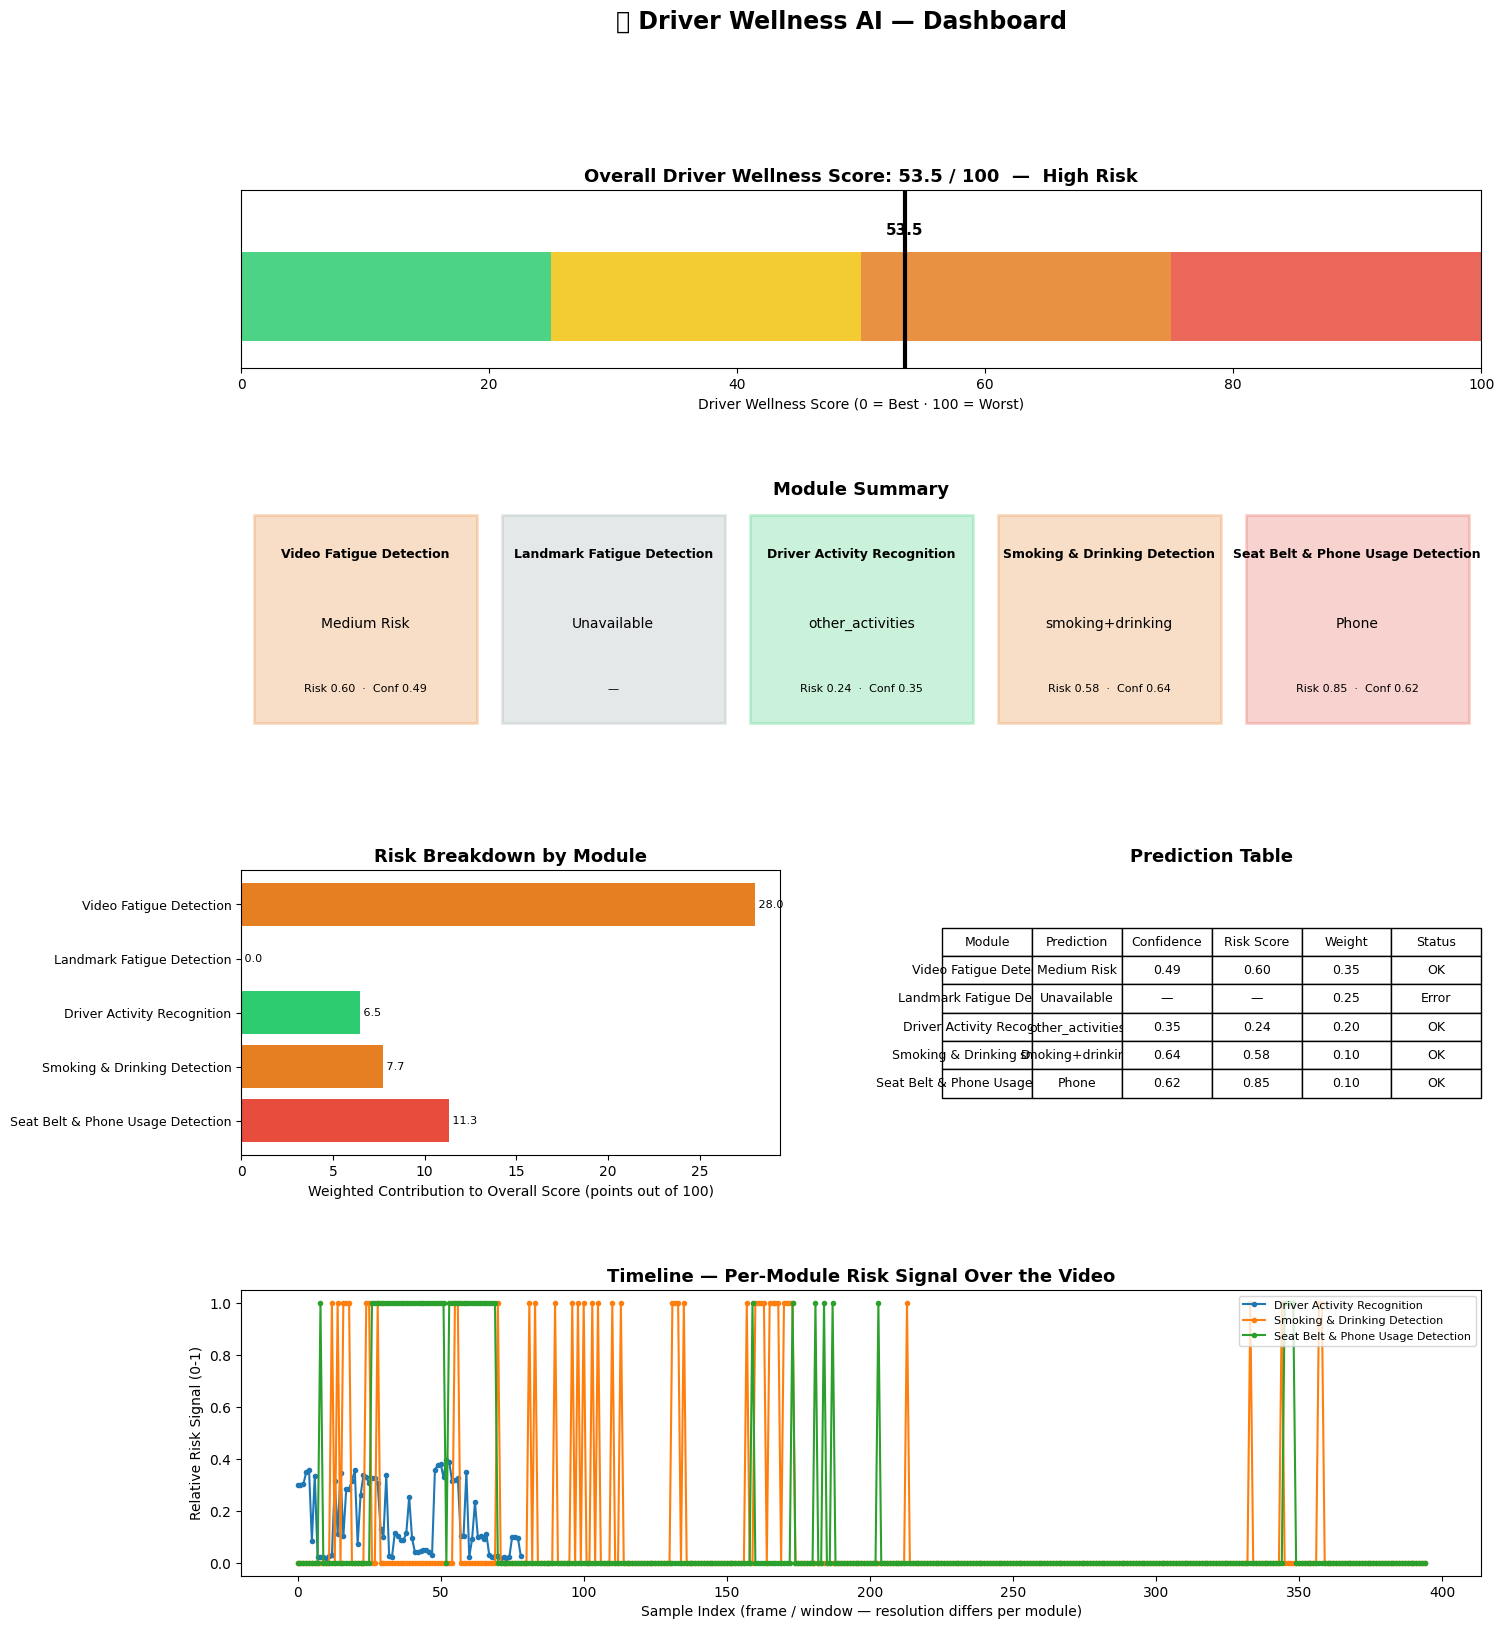


DRIVER WELLNESS SCORE
Overall Score : 53.5 / 100
Risk Level    : High Risk

  - Video Fatigue Detection        risk=0.60  weighted=28.0 pts
  - Landmark Fatigue Detection     risk=0.00  weighted=0.0 pts (unavailable — weight redistributed)
  - Driver Activity Recognition    risk=0.24  weighted=6.5 pts
  - Smoking & Drinking Detection   risk=0.58  weighted=7.7 pts
  - Seat Belt & Phone Usage Detection risk=0.85  weighted=11.3 pts


In [68]:
# ==========================================================
# Driver Wellness AI — End-to-End Demo
# ==========================================================
print("=" * 80)
print("Driver Wellness AI — End-to-End Pipeline")
print("=" * 80)

# 1. Create InferenceContext from the uploaded video (Section 5)
context = InferenceContext(video_path=video_path, device=DEVICE)
print(f"InferenceContext created for: {context.video_path}")

# 2. Run every registered adapter
print("\nRunning all modules...")
prediction_results = module_manager.run_all(context)

for result in prediction_results:
    status = "ERROR" if result.is_error else "OK"
    print(
        f"  [{status}] {result.module:<30} prediction={result.prediction!r:<20} "
        f"confidence={result.confidence:.2f} risk_score={result.risk_score:.2f}"
    )

# 3. Run Risk Fusion
print("\nRunning Risk Fusion Engine...")
fusion_result = risk_fusion_engine.fuse(prediction_results)

# 4. Display Dashboard
render_dashboard(prediction_results, fusion_result)

# 5. Print final Driver Wellness Score
print("\n" + "=" * 80)
print("DRIVER WELLNESS SCORE")
print("=" * 80)
print(f"Overall Score : {fusion_result['overall_score']:.1f} / 100")
print(f"Risk Level    : {fusion_result['risk_level']}")
print()
for contribution in fusion_result["contributions"]:
    availability_note = "" if contribution["available"] else " (unavailable — weight redistributed)"
    print(
        f"  - {contribution['module']:<30} "
        f"risk={contribution['risk_score']:.2f}  "
        f"weighted={contribution['weighted_contribution']:.1f} pts{availability_note}"
    )

# Release GPU/CPU memory now that the demo is complete.
module_manager.unload_all()